# Standardization

This is the process of transformation of continous data to appear normally distributed. 

1. `Scikit-learn` models assume normally distributed data.

2. Using non-normal training data can introduce bias.

3. Applies to continous numerical data.


## When to standardize:

1. Models that use linear space
   Ex : K-nearest Neighbors, Linear Regression, K-means Clustering.

2. Dataset features have high variance.

3. Features are on different scales.

4. Linearity Assumptions.




In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/wine.csv')
df

,Type,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [6]:
print(df.columns)

Index(['Type', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash',
       'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
       'Proanthocyanins', 'Color intensity', 'Hue',
       'OD280/OD315 of diluted wines', 'Proline'],
      dtype='object')


## Log Normalization

1. Useful when feature have high variance

2. Applies logarithm transformation

3. Natural Log  using the constant `e`(`~2.718`)

4. Capture relative changes, the magnitude of change, and keeps everything positive.


We will see how we can use the log normalization in the wine dataset.

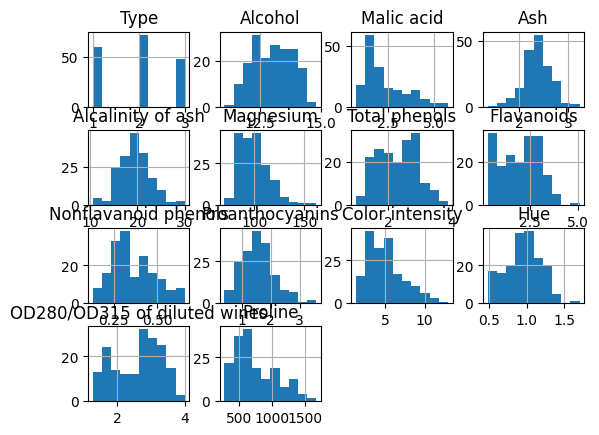

In [9]:
wine_df = df


#Checking corelation of data
wine_df.hist(bins=10)
plt.show()


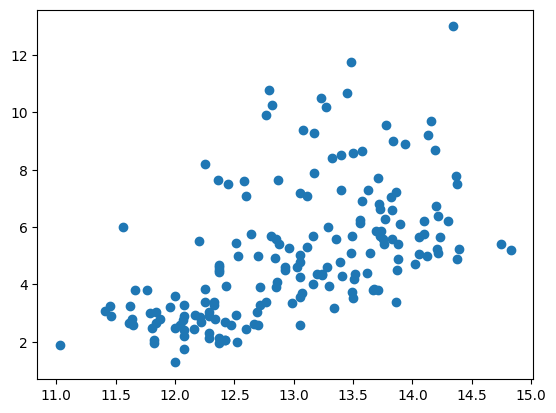

In [21]:
plt.scatter(wine_df['Alcohol'],wine_df['Color intensity'])
plt.show()

In [23]:
print(wine_df.dtypes)

Type                              int64
Alcohol                         float64
Malic acid                      float64
Ash                             float64
Alcalinity of ash               float64
Magnesium                         int64
Total phenols                   float64
Flavanoids                      float64
Nonflavanoid phenols            float64
Proanthocyanins                 float64
Color intensity                 float64
Hue                             float64
OD280/OD315 of diluted wines    float64
Proline                           int64
dtype: object


In [ ]:
# Creating X and Y sets
X = wine_df['Alcohol']
y = wine_df['Color intensity']


# Variance Check
print(f"Variance of X before normalization {X.var()}")
print(f"Variance of Y before normalization {y.var()}")


0.6590623278105759
5.374449383491404


In [28]:
# Log normalization
import numpy as np

y = np.log(y)
print(f"Variance of X After normalization {X.var()}")
print(f"Variance of Y After normalization {y.var()}")


Variance of X After normalization 0.6590623278105759
Variance of Y After normalization 0.6089316027794047


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Sclaing data or feature Scalling

1. Feature scalling is dont when certain features are at a different scale.

2. Model with linear charectarsitics

3. Center features around 0 and transform to variance 1.

4. Transform to approxiamately normal distribution.

In [29]:
Scale_df = df

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


df_scaled = pd.DataFrame(scaler.fit_transform(df),
            columns=df.columns)

print(df_scaled)



         Type   Alcohol  Malic acid       Ash  Alcalinity of ash  Magnesium  \
0   -1.213944  1.518613   -0.562250  0.232053          -1.169593   1.913905   
1   -1.213944  0.246290   -0.499413 -0.827996          -2.490847   0.018145   
2   -1.213944  0.196879    0.021231  1.109334          -0.268738   0.088358   
3   -1.213944  1.691550   -0.346811  0.487926          -0.809251   0.930918   
4   -1.213944  0.295700    0.227694  1.840403           0.451946   1.281985   
..        ...       ...         ...       ...                ...        ...   
173  1.373864  0.876275    2.974543  0.305159           0.301803  -0.332922   
174  1.373864  0.493343    1.412609  0.414820           1.052516   0.158572   
175  1.373864  0.332758    1.744744 -0.389355           0.151661   1.422412   
176  1.373864  0.209232    0.227694  0.012732           0.151661   1.422412   
177  1.373864  1.395086    1.583165  1.365208           1.502943  -0.262708   

     Total phenols  Flavanoids  Nonflavanoid phenol

## Standardized data and modeling



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


X = df['Ash']
Y = df[['Alcalinity of ash','Magnesium']]


X_train, X_test, y_train ,y_test = train_test_split(X,Y, stratify=Y, random_state=42)

knn= KNeighborsClassifier()
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


knn.fit(X_train_scaled,y_train)
knn.score(X_test_scaled,y_test)
